# Readout ADC noise spectrum (QRM_RF, slot 8)

Same measurement as `test.ipynb` (QRC, slot 13), repeated on the QRM_RF module in slot 8 of the
same cluster (`192.168.1.242`) for comparison. A 50 ohm terminator is connected to the physical
readout-in port, so the acquired traces contain no real signal, only system noise. This notebook
talks to the Cluster directly through `qblox_instruments` and does **not** read any
hardware/device config JSON file — every connection and sweep parameter is set explicitly in the
cell below so it is easy to change for a different test.


In [1]:
import atexit
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from qblox_instruments import Cluster
from qcodes.instrument import Instrument


## Run parameters

In [2]:
CLUSTER_NAME = "cluster_A"
CLUSTER_IP = "192.168.1.242"
MODULE_SLOT = 8  # QRM_RF

READOUT_LO_FREQ = 4e9  # Hz, fixed LO for the readout in/out mixer (out0_in0_lo_freq)
IF_FREQUENCIES = list(np.arange(-400e6, 600e6, 200e6))  # Hz, swept one at a time via sequencer NCO
REPETITIONS = 100  # raw traces captured per IF point

ACQUISITION_DURATION_NS = 16384  # ns, scope-acquisition hardware maximum (1 GSa/s -> 16384 samples)
ACQUISITION_DT = 1e-9  # s, scope acquisition sample spacing (1 GSa/s)

OUTPUT_ATT = 0  # dB, out0_att
INPUT_ATT = 0  # dB, in0_att

OUTPUT_DIR = Path("data")
OUTPUT_DIR.mkdir(exist_ok=True)


## Connect to hardware and configure the QRM_RF

In [3]:
cluster = Cluster(CLUSTER_NAME, CLUSTER_IP)
atexit.register(Instrument.close_all)

module = getattr(cluster, f"module{MODULE_SLOT}")
assert module.is_qrm_type and module.is_rf_type, f"slot {MODULE_SLOT} is not a QRM_RF module"

module.out0_in0_lo_freq(READOUT_LO_FREQ)
module.out0_att(OUTPUT_ATT)
module.in0_att(INPUT_ATT)

sequencer = module.sequencer0
sequencer.connect_acq("in0")

# Scope-mode (raw ADC trace) acquisition, hardware averaging off so every repetition is
# captured individually and averaging/statistics are done in this notebook instead.
module.scope_acq_trigger_mode_path0("sequencer")
module.scope_acq_trigger_mode_path1("sequencer")
module.scope_acq_avg_mode_en_path0(False)
module.scope_acq_avg_mode_en_path1(False)
module.scope_acq_sequencer_select(0)

# Minimal Q1ASM: no `play`, just arm + listen for ACQUISITION_DURATION_NS and stop -- the
# readout-in port only sees whatever noise is present (terminator, no stimulus pulse).
program = f"""
setup:
    wait_sync 4
    reset_ph
    upd_param 4
    acquire 0,0,{ACQUISITION_DURATION_NS}
    stop
"""
sequencer.sequence(
    {
        "waveforms": {},
        "weights": {},
        "acquisitions": {"noise": {"num_bins": 1, "index": 0}},
        "program": program,
    }
)

print(f"Connected to {CLUSTER_NAME} @ {CLUSTER_IP}, module {MODULE_SLOT} (QRM_RF), LO = {READOUT_LO_FREQ / 1e9:g} GHz")


Connected to cluster_A @ 192.168.1.242, module 8 (QRM_RF), LO = 4 GHz


## Acquire raw ADC noise traces

In [4]:
def acquire_one_trace():
    sequencer.delete_acquisition_data(name="noise")
    sequencer.arm_sequencer()
    sequencer.start_sequencer()
    sequencer.get_sequencer_status(timeout=10)
    sequencer.store_scope_acquisition("noise")
    scope = sequencer.get_acquisitions()["noise"]["acquisition"]["scope"]
    path0 = np.array(scope["path0"]["data"])
    path1 = np.array(scope["path1"]["data"])
    return path0 + 1j * path1


traces_by_if = {}
for if_freq in IF_FREQUENCIES:
    sequencer.nco_freq(if_freq)
    traces = np.array([acquire_one_trace() for _ in range(REPETITIONS)])
    traces_by_if[if_freq] = traces
    print(f"IF = {if_freq / 1e6:+.0f} MHz: acquired {traces.shape[0]} traces of {traces.shape[1]} samples")

np.savez(
    OUTPUT_DIR / "readout_adc_noise_traces_module8.npz",
    if_frequencies=np.array(IF_FREQUENCIES),
    **{f"if_{int(if_freq)}": traces for if_freq, traces in traces_by_if.items()},
)


IF = -400 MHz: acquired 100 traces of 16384 samples
IF = -200 MHz: acquired 100 traces of 16384 samples
IF = +0 MHz: acquired 100 traces of 16384 samples
IF = +200 MHz: acquired 100 traces of 16384 samples
IF = +400 MHz: acquired 100 traces of 16384 samples


## Raw data

Plot the raw ADC traces before any FFT, so the time-domain data can be sanity-checked first.

In [5]:
# time_ns = np.arange(next(iter(traces_by_if.values())).shape[1]) / ACQUISITION_DT / 1e9

# fig, axes = plt.subplots(len(IF_FREQUENCIES), 2, figsize=(10, 2.2 * len(IF_FREQUENCIES)), sharex=True)
# for row, if_freq in enumerate(IF_FREQUENCIES):
#     traces = traces_by_if[if_freq]
#     ax_iq, ax_abs = axes[row]

#     for trace in traces:
#         ax_iq.plot(time_ns, trace.real, color="C0", alpha=0.1, linewidth=0.5)
#         ax_iq.plot(time_ns, trace.imag, color="C1", alpha=0.1, linewidth=0.5)
#     ax_iq.plot(time_ns, traces.real.mean(axis=0), color="C0", label="I (mean)")
#     ax_iq.plot(time_ns, traces.imag.mean(axis=0), color="C1", label="Q (mean)")
#     ax_iq.set_ylabel(f"IF = {if_freq / 1e6:+.0f} MHz\nADC counts")
#     ax_iq.legend(loc="upper right", fontsize=8)

#     for trace in traces:
#         ax_abs.plot(time_ns, np.abs(trace), color="C2", alpha=0.1, linewidth=0.5)
#     ax_abs.plot(time_ns, np.abs(traces).mean(axis=0), color="C2", label="|trace| (mean)")
#     ax_abs.legend(loc="upper right", fontsize=8)

# axes[0, 0].set_title("I / Q raw traces (all repetitions, faint) + mean")
# axes[0, 1].set_title("|I + jQ| raw traces (all repetitions, faint) + mean")
# axes[-1, 0].set_xlabel("Time (ns)")
# axes[-1, 1].set_xlabel("Time (ns)")
# fig.tight_layout()
plt.show()

## Analysis: noise power spectrum

In [6]:
def noise_power_spectrum(traces_complex, dt=ACQUISITION_DT, use_abs=True):
    # Remove the common-mode/systematic offset shared by all repetitions.
    demeaned = traces_complex - traces_complex.mean(axis=0, keepdims=True)
    signal = np.abs(demeaned) if use_abs else demeaned
    spectra = np.abs(np.fft.rfft(signal, axis=1)) ** 2 if use_abs else np.abs(np.fft.fft(signal, axis=1)) ** 2
    psd = spectra.mean(axis=0)
    freqs = (
        np.fft.rfftfreq(signal.shape[1], d=dt)
        if use_abs
        else np.fft.fftfreq(signal.shape[1], d=dt)
    )
    if not use_abs:
        order = np.argsort(freqs)
        freqs, psd = freqs[order], psd[order]
    return freqs, psd


# "abs" version: matches the originally requested workflow (demean -> abs -> FFT -> average).
# Rectifying (abs) is a nonlinear step that discards phase and tends to whiten/flatten the
# spectrum regardless of the true underlying noise color, so treat this as an amplitude-envelope
# spectrum rather than a proper noise PSD.
psd_by_if = {if_freq: noise_power_spectrum(traces, use_abs=True) for if_freq, traces in traces_by_if.items()}

# "complex" version: demean -> FFT directly on the complex I+jQ trace (no abs) -> average |FFT|^2.
# This preserves the true frequency-domain structure (e.g. filter/mixer roll-off) and is the
# standard way to estimate a PSD.
psd_complex_by_if = {if_freq: noise_power_spectrum(traces, use_abs=False) for if_freq, traces in traces_by_if.items()}

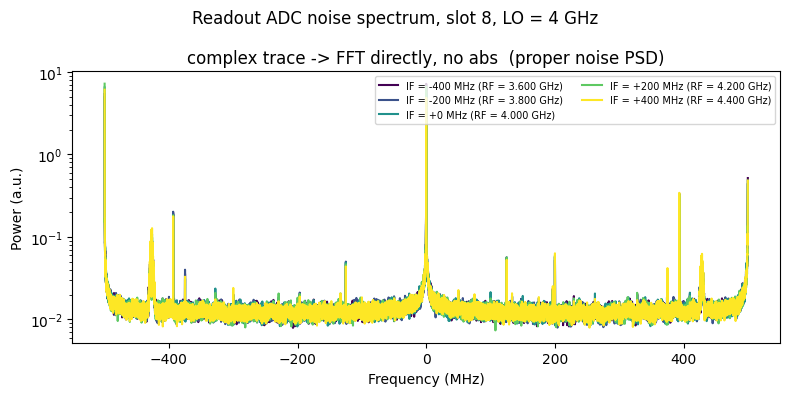

In [7]:
cmap = plt.cm.viridis
colors = {if_freq: cmap(i / max(len(IF_FREQUENCIES) - 1, 1)) for i, if_freq in enumerate(IF_FREQUENCIES)}

fig, (ax_complex) = plt.subplots(1, 1, figsize=(8, 4), sharex=False)

for if_freq, (freqs, psd) in psd_complex_by_if.items():
    rf_freq = READOUT_LO_FREQ + if_freq
    ax_complex.plot(
        freqs / 1e6,
        psd,
        color=colors[if_freq],
        label=f"IF = {if_freq / 1e6:+.0f} MHz (RF = {rf_freq / 1e9:.3f} GHz)",
    )
ax_complex.set_xlabel("Frequency (MHz)")
ax_complex.set_ylabel("Power (a.u.)")
ax_complex.set_title("complex trace -> FFT directly, no abs  (proper noise PSD)")
ax_complex.legend(fontsize=7, ncol=2)
ax_complex.set_yscale("log")
fig.suptitle(f"Readout ADC noise spectrum, slot {MODULE_SLOT}, LO = {READOUT_LO_FREQ / 1e9:g} GHz")
fig.tight_layout()
plt.show()

## Convert to physical units (V²/Hz)

The scope acquisition data returned by `get_acquisitions()` is normalized to a dimensionless range of -1.0 to 1.0 relative to the ADC full scale (per the `qblox_instruments` docstring for `get_acquisitions`); it is not volts. The QRM-RF product sheet specifies `Max. input power (into 50 Ω): -26 to 0 dBm (settable)` together with `in0_att` covering 0-30 dB in 2 dB steps, i.e. full scale (normalized amplitude = 1.0) corresponds to an input power of -26 dBm at `in0_att = 0 dB` (the most sensitive end), increasing roughly 1 dB per 1 dB of added attenuation. That lets us turn the normalized trace into volts and compute a proper PSD in V²/Hz instead of arbitrary units.

This figure is confirmed directly from the QRM-RF product sheet (`QBLOX_PRODUCTSHEET_QRM-RF_V1_7.pdf`), which is the module used here.

Full scale (normalized amplitude = 1.0) = 15.85 mV_peak (-26.0 dBm into 50 Ω, at in0_att = 0 dB)


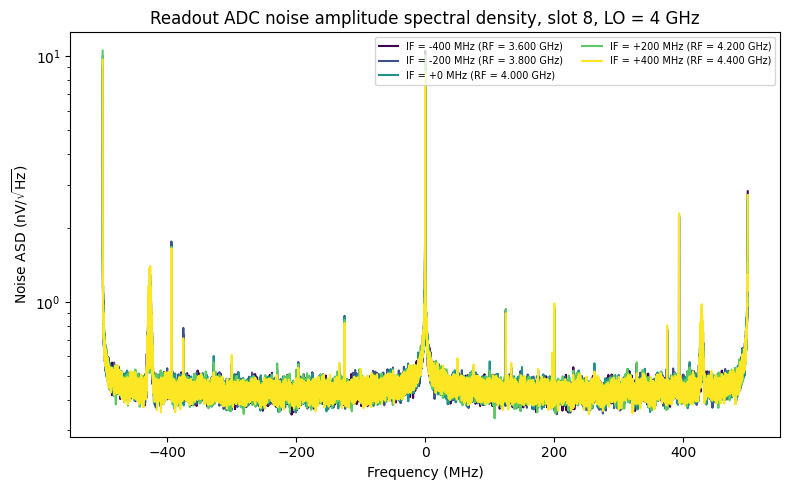

In [8]:
# ADC full-scale calibration, from the QRM-RF product sheet
# (Max. input power into 50 ohm: -26 to 0 dBm, settable via in0_att = 0-30 dB).
ADC_FULLSCALE_DBM_AT_0DB_ATT = -26.0  # dBm, normalized amplitude 1.0 at in0_att = 0 dB
R_LOAD_OHM = 50.0

fullscale_dbm = ADC_FULLSCALE_DBM_AT_0DB_ATT + INPUT_ATT
fullscale_power_w = 10 ** (fullscale_dbm / 10) * 1e-3
fullscale_vrms = np.sqrt(fullscale_power_w * R_LOAD_OHM)
fullscale_vpeak = fullscale_vrms * np.sqrt(2)
print(
    f"Full scale (normalized amplitude = 1.0) = {fullscale_vpeak * 1e3:.2f} mV_peak "
    f"({fullscale_dbm:.1f} dBm into {R_LOAD_OHM:g} \u03a9, at in0_att = {INPUT_ATT} dB)"
)


def noise_psd_volts(traces_complex, dt=ACQUISITION_DT):
    traces_v = traces_complex * fullscale_vpeak
    demeaned = traces_v - traces_v.mean(axis=0, keepdims=True)
    n = demeaned.shape[1]
    fs = 1 / dt
    spectra = (np.abs(np.fft.fft(demeaned, axis=1)) ** 2) / (n * fs)  # V^2/Hz
    psd = spectra.mean(axis=0)
    freqs = np.fft.fftfreq(n, d=dt)
    order = np.argsort(freqs)
    return freqs[order], psd[order]


psd_volts_by_if = {if_freq: noise_psd_volts(traces) for if_freq, traces in traces_by_if.items()}

fig, ax = plt.subplots(figsize=(8, 5))
for if_freq, (freqs, psd) in psd_volts_by_if.items():
    rf_freq = READOUT_LO_FREQ + if_freq
    asd_nv = np.sqrt(psd) * 1e9  # V/sqrt(Hz) -> nV/sqrt(Hz)
    ax.plot(
        freqs / 1e6,
        asd_nv,
        color=colors[if_freq],
        label=f"IF = {if_freq / 1e6:+.0f} MHz (RF = {rf_freq / 1e9:.3f} GHz)",
    )
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel(r"Noise ASD (nV/$\sqrt{\mathrm{Hz}}$)")
ax.set_yscale("log")
ax.set_title(f"Readout ADC noise amplitude spectral density, slot {MODULE_SLOT}, LO = {READOUT_LO_FREQ / 1e9:g} GHz")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

## Locate the spur: peak frequency vs. inferred absolute RF

For each IF setting, find the strongest peak in the complex-FFT spectrum away from DC and convert its baseband frequency back to an absolute RF frequency (`RF = LO + IF + f_peak`). If a real fixed-frequency spur exists, this inferred RF should stay roughly constant across all IF settings even though `f_peak` itself moves.

In [9]:
DC_GUARD_MHZ = 20  # ignore bins within this many MHz of DC when searching for the peak

print(f"{'IF (MHz)':>10} | {'peak f (MHz)':>13} | {'peak power':>10} | {'inferred RF (GHz)':>18}")
for if_freq in IF_FREQUENCIES:
    freqs, psd = psd_complex_by_if[if_freq]
    mask = np.abs(freqs) > DC_GUARD_MHZ * 1e6
    i_peak = np.argmax(psd[mask])
    f_peak = freqs[mask][i_peak]
    p_peak = psd[mask][i_peak]
    rf_inferred = (READOUT_LO_FREQ + if_freq + f_peak) / 1e9
    print(f"{if_freq / 1e6:10.0f} | {f_peak / 1e6:13.1f} | {p_peak:10.2f} | {rf_inferred:18.4f}")

  IF (MHz) |  peak f (MHz) | peak power |  inferred RF (GHz)
      -400 |        -500.0 |       5.39 |             3.1000
      -200 |        -500.0 |       4.93 |             3.3000
         0 |        -500.0 |       6.49 |             3.5000
       200 |        -500.0 |       7.21 |             3.7000
       400 |        -500.0 |       6.09 |             3.9000


## Release hardware connection

In [10]:
Instrument.close_all()
